# Step B — Interannual weather-year sensitivity

**Task (Assignment 1, part b):** Investigate how sensitive the Step A results are to the
interannual variability of solar and wind generation. Plot the average capacity and
variability for every generator across different weather years.

We re-run the Step A optimisation for weather years **2015, 2016, 2017, 2018** with the
same cost assumptions, and compare installed capacities, annual production, capacity
factors, duration curves, and dispatch during representative weeks.

**Requires in the working directory:**
- `DK_2015_merged.csv`, `DK_2016_merged.csv`, `DK_2017_merged.csv`, `DK_2018_merged.csv`
- `functions_to_investigate.py`


## Imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pypsa
import importlib
import functions_to_investigate as fti


## Cost assumptions (same as Step A)

We keep the Step A cost table unchanged so that any difference between years comes from
the weather, not from the cost inputs.


In [2]:
data = {
    "capital_cost": [
        1500000/25 + 60000,   # wind:  120,000 $/MW/year
        800000/25 + 14000,    # solar:  46,000 $/MW/year
        700000/25 + 24000,    # CCGT:   52,000 $/MW/year
    ],
    "marginal_cost": [0.0, 0.0, 9.5 * 3.6 / 0.56 + 2.30]  # CCGT: ~63.4 $/MWh
}
costs = pd.DataFrame(data, index=["wind_combined", "solar", "CCGT"])
costs


,capital_cost,marginal_cost
wind_combined,120000.0,0.000000
solar,46000.0,0.000000
CCGT,52000.0,63.371429


## Sweep across weather years

We loop 2015 → 2018, rebuild the same single-node Denmark model with that year's hourly
demand and capacity factors, optimise, and store the resulting network together with a
summary of capacities, production and capacity factors.


In [3]:
# optimization for each weather year
years = [2015, 2016, 2017, 2018]
results = {}

for year in years:
    df = pd.read_csv(f"DK_{year}_merged.csv", index_col=0, sep=",", parse_dates=True)

    n = pypsa.Network()
    n.set_snapshots(df.index.values)
    n.add("Bus", "Denmark")
    n.add("Carrier", ["wind_combined", "solar", "CCGT"], color=["blue", "red", "brown"])

    n.add("Load", "dnk_demand", bus="Denmark",
          p_set=df["DK_load_actual_entsoe_transparency"].values)

    n.add("Generator", "wind_combined", bus="Denmark", carrier="wind_combined",
          capital_cost=costs.loc["wind_combined", "capital_cost"],
          marginal_cost=costs.loc["wind_combined", "marginal_cost"],
          p_max_pu=df["wind_cf_Unnamed: 1"].values, p_nom_extendable=True)

    n.add("Generator", "solar", bus="Denmark", carrier="solar",
          capital_cost=costs.loc["solar", "capital_cost"],
          marginal_cost=costs.loc["solar", "marginal_cost"],
          p_max_pu=df["pv_cf_Unnamed: 1"].values, p_nom_extendable=True)

    n.add("Generator", "CCGT", bus="Denmark", carrier="CCGT",
          capital_cost=costs.loc["CCGT", "capital_cost"],
          marginal_cost=costs.loc["CCGT", "marginal_cost"],
          efficiency=0.58, p_nom_extendable=True)

    n.optimize(solver_name="gurobi", solver_options={"output_flag": False})

    results[year] = {
        "network": n,
        "p_nom_opt": n.generators.p_nom_opt.copy(),
        "production_twh": n.generators_t.p.sum() / 1e6,
        "cf_wind": df["wind_cf_Unnamed: 1"].mean(),
        "cf_solar": df["pv_cf_Unnamed: 1"].mean(),
        "objective": n.objective,
    }


C:\Users\terry\AppData\Local\Temp\ipykernel_5312\3035408934.py:31: FutureWarning:

The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.

Index(['Denmark'], dtype='str', name='name')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.model:Solver options:
 - output_flag: False
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 2/2 [00:00<00:00, 239.86it/s]
INFO:linopy.io: Writing time: 0.08s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2773895


INFO:gurobipy:Set parameter LicenseID to value 2773895


...

INFO:gurobipy:Read LP format model from file C:\Users\terry\AppData\Local\Temp\linopy-problem-hd_gc1tq.lp


Reading time = 0.08 seconds


INFO:gurobipy:Reading time = 0.08 seconds


obj: 61323 rows, 26283 columns, 100713 nonzeros


INFO:gurobipy:obj: 61323 rows, 26283 columns, 100713 nonzeros
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 26283 primals, 61323 duals
Objective: 2.06e+09
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper were not assigned to the network.


## Summary table across all years

In [4]:
# Summary table for all years
rows = []
for year in years:
    r = results[year]
    rows.append({
        ("Capacity", "Wind [GW]"): round(r["p_nom_opt"]["wind_combined"] / 1e3, 2),
        ("Capacity", "Solar [GW]"): round(r["p_nom_opt"]["solar"] / 1e3, 2),
        ("Capacity", "CCGT [GW]"): round(r["p_nom_opt"]["CCGT"] / 1e3, 2),
        ("Generation", "Wind [TWh/y]"): round(r["production_twh"]["wind_combined"], 1),
        ("Generation", "Solar [TWh/y]"): round(r["production_twh"]["solar"], 1),
        ("Generation", "CCGT [TWh/y]"): round(r["production_twh"]["CCGT"], 1),
        ("Objective", "System Cost [B$/y]"): round(r["objective"] / 1e9, 3),
    })

opt_results = pd.DataFrame(rows, index=years)
opt_results.index.name = "Year"
opt_results.columns = pd.MultiIndex.from_tuples(opt_results.columns)

opt_results


Capacity                        Generation                             \
     Wind [GW] Solar [GW] CCGT [GW] Wind [TWh/y] Solar [TWh/y] CCGT [TWh/y]   
Year                                                                          
2015      6.10       3.27      5.34         18.7           2.8         11.3   
2016      5.95       4.05      5.17         16.2           3.7         12.4   
2017      6.28       2.64      5.20         18.3           2.2         12.0   
2018      6.32       4.25      6.45         17.5           3.9         12.2   

              Objective  
     System Cost [B$/y]  
Year                     
2015              1.873  
2016              1.953  
2017              1.902  
2018              2.062

## Plots — capacities, production, capacity factors across years

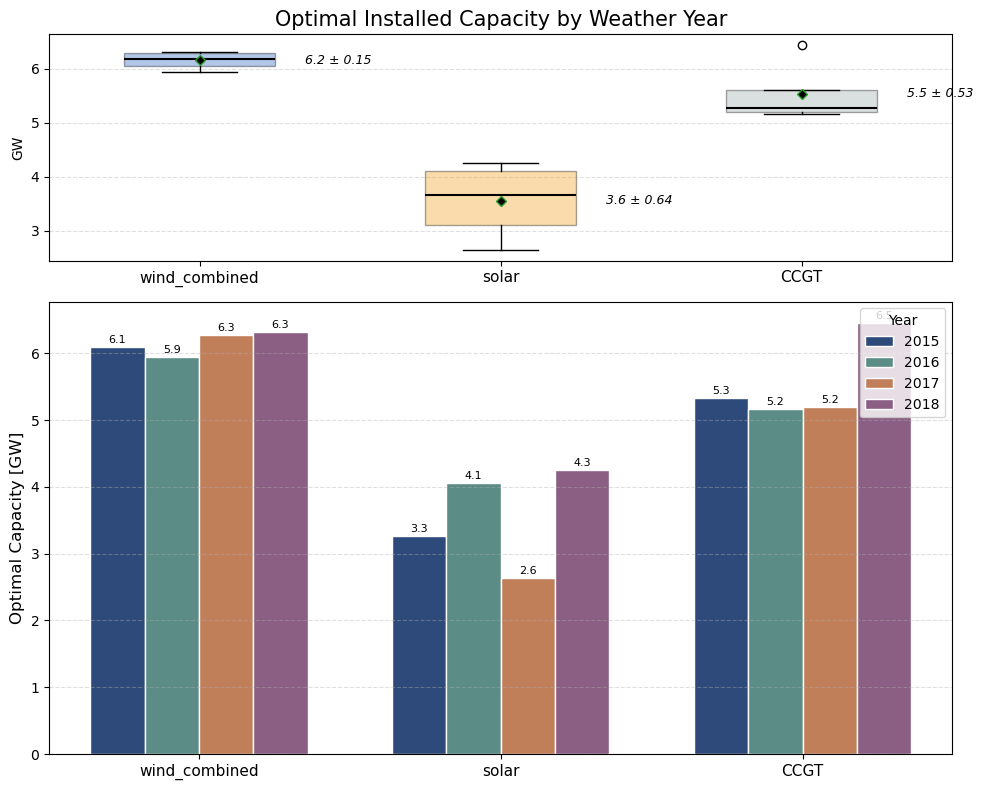

In [5]:
# Capacities per year
fti.plot_capacity_by_year(results)


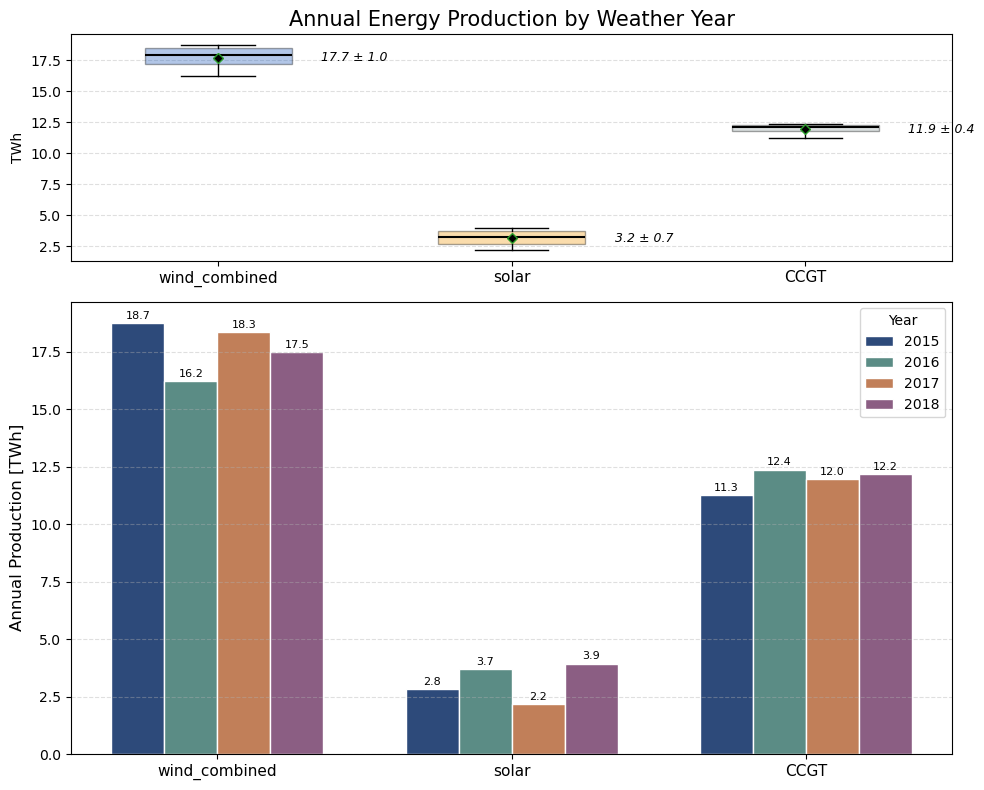

In [6]:
# Production per year
fti.plot_production_by_year(results)


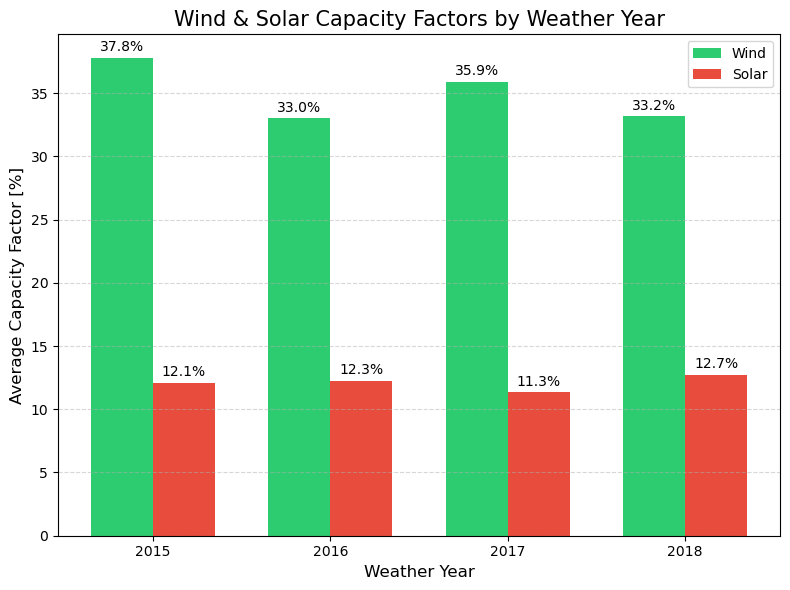

In [7]:
# Capacity factors per year
fti.plot_cf_by_year(results)


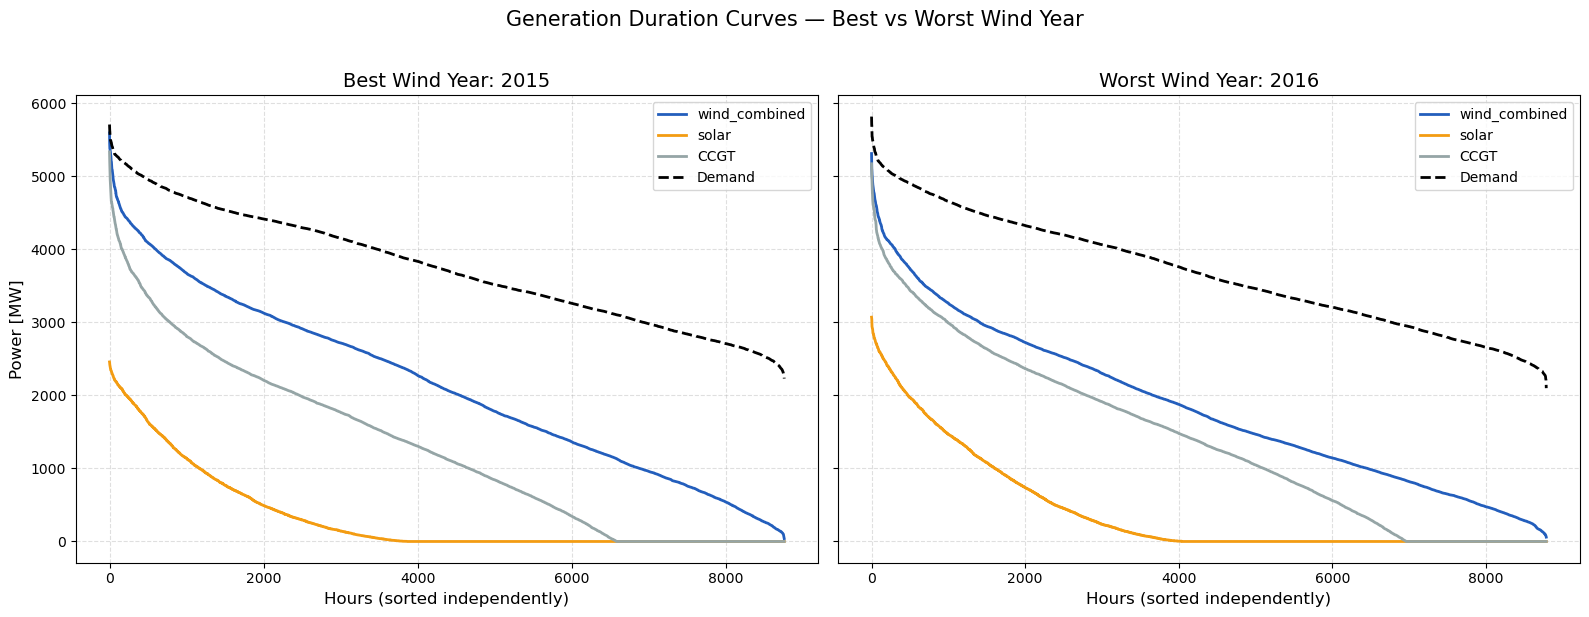

In [8]:
# Duration curves: best vs worst wind year
fti.plot_duration_curves_comparison(results, resource="wind")


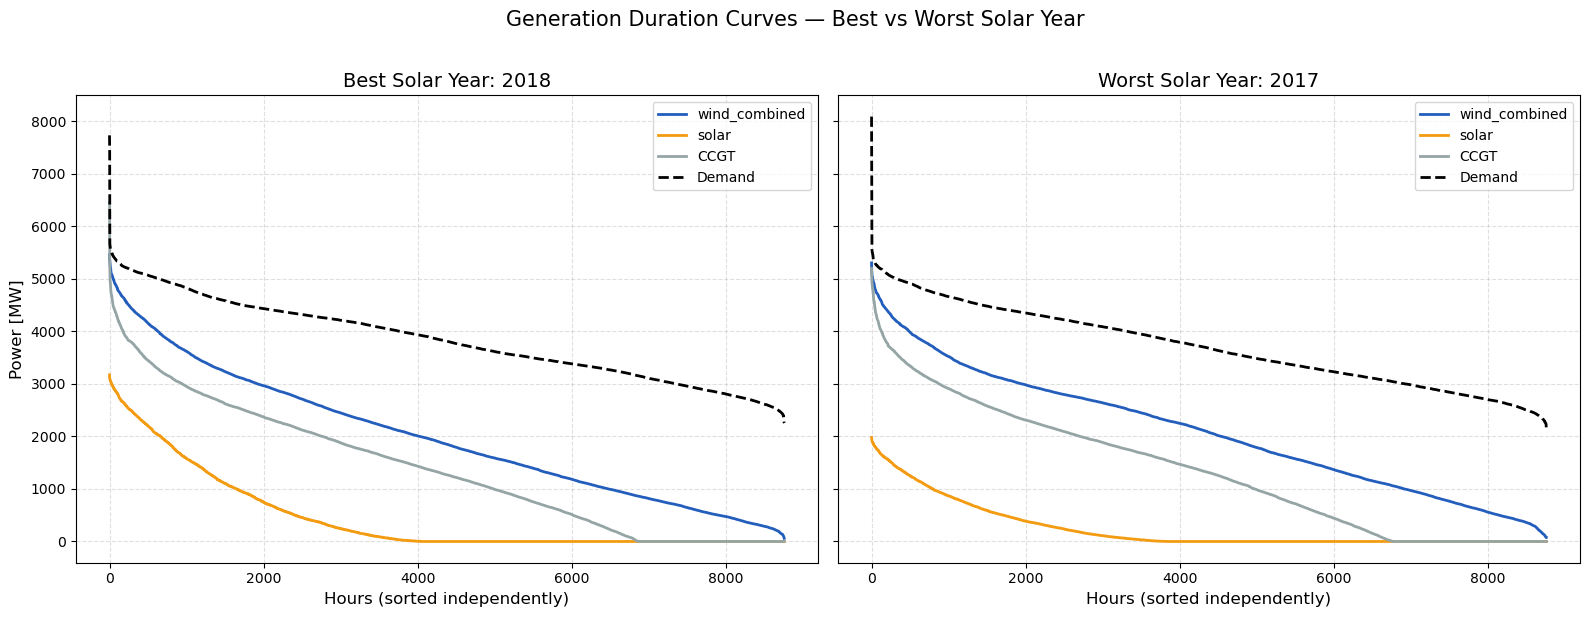

In [9]:
# Duration curves: best vs worst solar year
fti.plot_duration_curves_comparison(results, resource="solar")


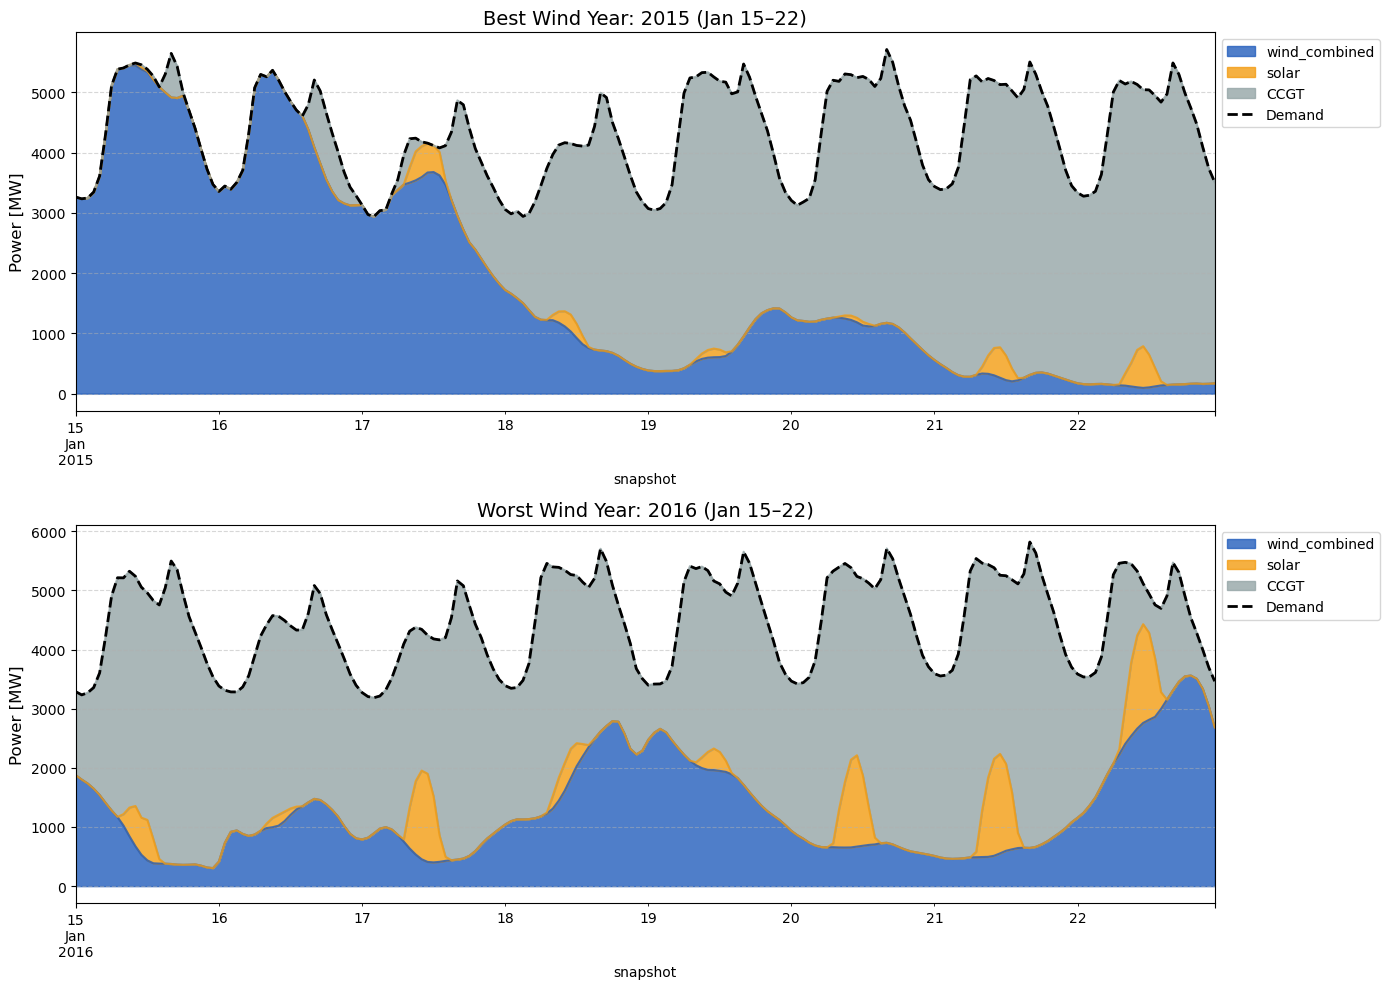

In [10]:
# Dispatch comparison: best vs worst wind year — zoom on a January week
fti.plot_dispatch_best_worst(results)


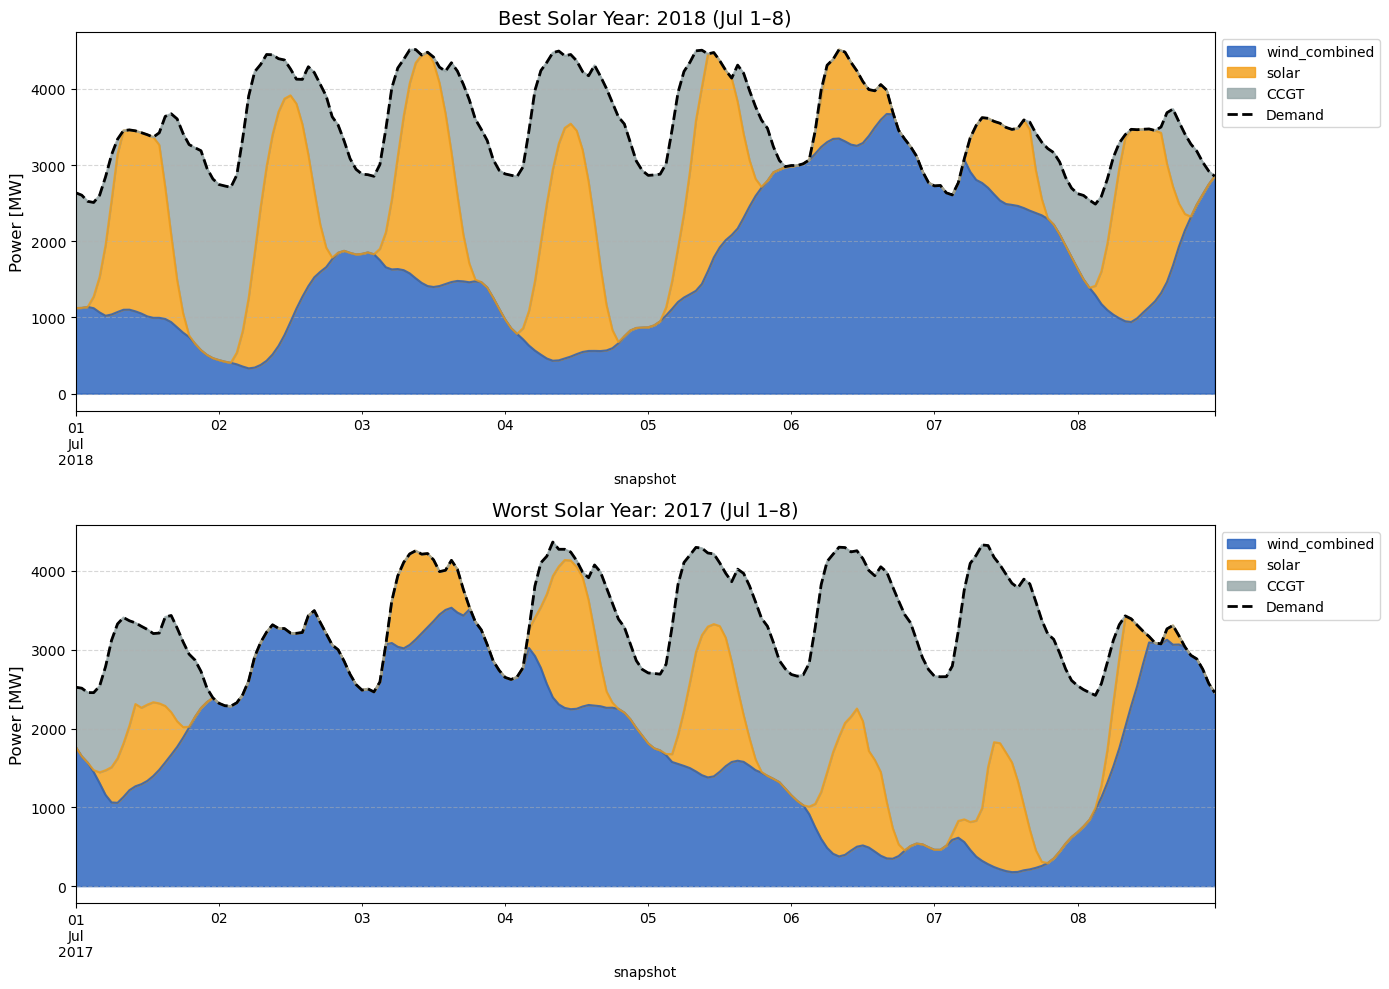

In [11]:
# Dispatch comparison: best vs worst solar year — zoom on a July week
fti.plot_dispatch_best_worst_solar(results)


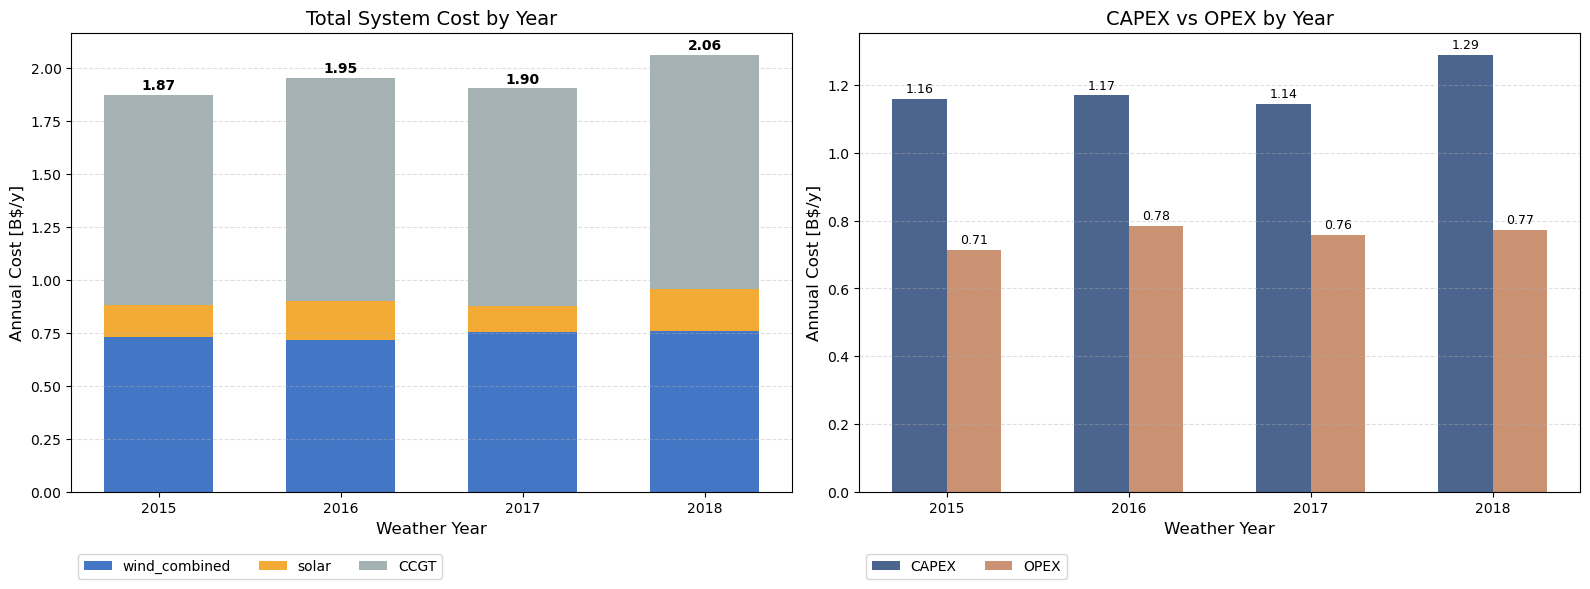

In [12]:
importlib.reload(fti)
fti.plot_economic_comparison(results)


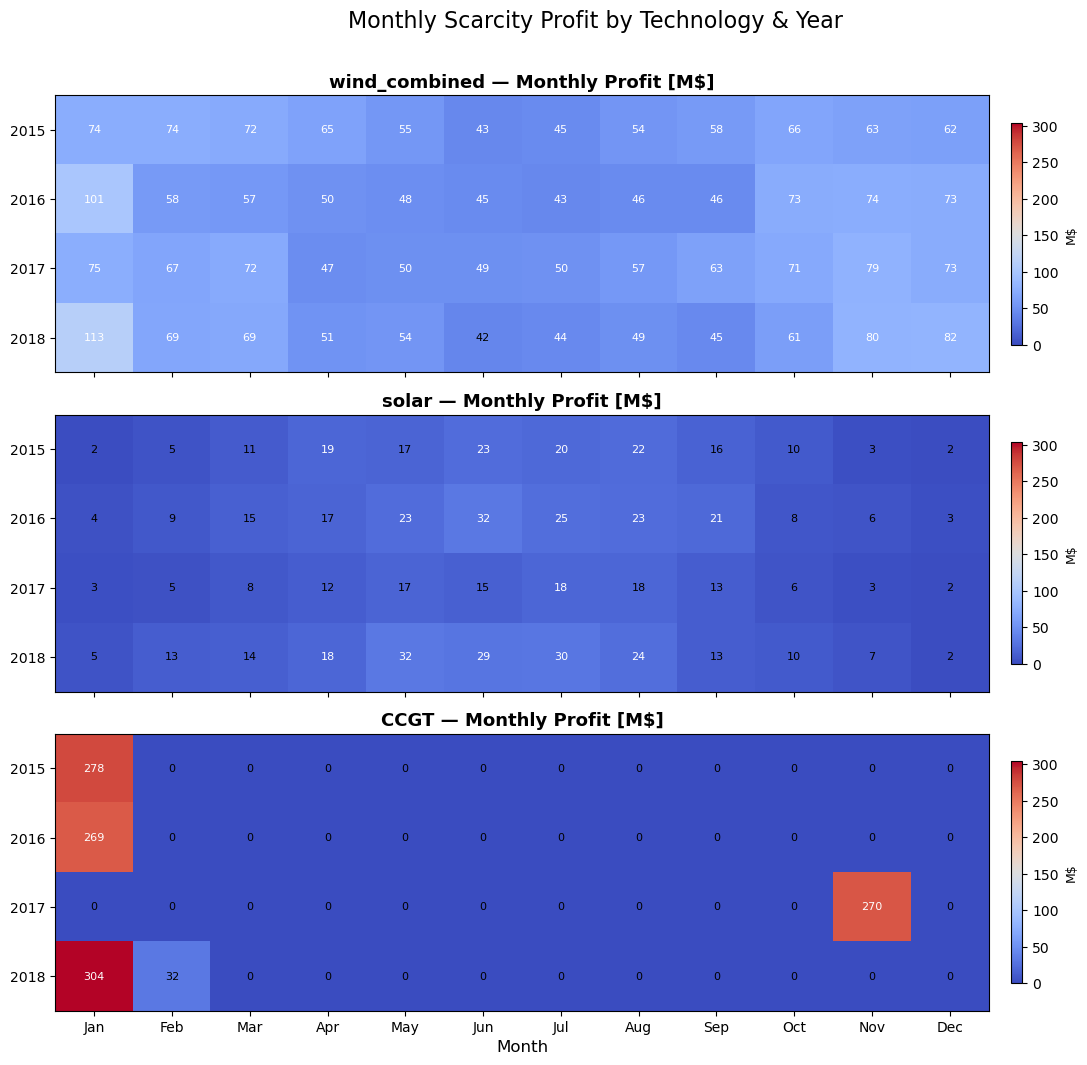

In [13]:
importlib.reload(fti)
fti.plot_profit_heatmap(results)
